# 第11回：多目的最適化（Multi-Objective Optimization）


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture11_multi_objective_optuna.ipynb)


## 0. このページで学ぶこと

ここまでの多くの最適化では，目的関数を 1 つに決めて

$$
\min_{\boldsymbol{x}\in\mathcal{X}} f(\boldsymbol{x})
$$

のように書いてきた。しかし，現実の意思決定では「安くしたいが，性能も落としたくない」「軽くしたいが，強度も欲しい」「配送時間を短くしたいが，費用も抑えたい」のように，複数の目的が同時に現れる。

このページでは，次の 4 点を学ぶ。

1. 多目的最適化では「1 個の最適解」ではなく「トレードオフの集合」を扱うこと。
2. パレート優越とパレート最適の定義。
3. Optuna を使って多目的最適化を実行し，パレートフロントを可視化すること。
4. PBL のテーマを，多目的最適化問題として定式化する見方。


(sec:moo-problem)=

## 1. 多目的最適化が解きたい問題

目的が $m$ 個あるとき，候補解 $\boldsymbol{x}$ に対する評価値を

$$
\boldsymbol{f}(\boldsymbol{x})
= \left(f_1(\boldsymbol{x}), f_2(\boldsymbol{x}), \ldots, f_m(\boldsymbol{x})\right)
$$

と書く。すべてを最小化する問題なら

$$
\min_{\boldsymbol{x}\in\mathcal{X}}
\left(f_1(\boldsymbol{x}), f_2(\boldsymbol{x}), \ldots, f_m(\boldsymbol{x})\right)
$$

である。

ただし，この式は 1 目的最適化の式よりも注意して読む必要がある。ベクトルには普通の大小関係がないため，ある解が別の解より「必ず良い」と言えるとは限らない。たとえば候補 A は安いが遅く，候補 B は高いが速い場合，どちらを選ぶべきかは利用者の価値判断に依存する。


### 1.1 最大化目的と最小化目的が混ざる場合

実務では，最小化したい目的と最大化したい目的が混ざることが多い。たとえば

$$
\text{cost}(\boldsymbol{x}) \downarrow,\qquad
\text{performance}(\boldsymbol{x}) \uparrow
$$

のような問題である。

数学的には，最大化目的 $g(\boldsymbol{x})$ を $-g(\boldsymbol{x})$ に変換すれば，すべて最小化として扱える。Optuna では `directions=["minimize", "maximize"]` のように目的ごとの向きを直接指定できるので，コード上ではこの変換を明示しなくてもよい。


(sec:pareto-dominance)=

## 2. パレート優越

まず，すべての目的を最小化するとして考える。

2 つの候補解 $\boldsymbol{x}$ と $\boldsymbol{y}$ について，次の 2 条件が成り立つとき，$\boldsymbol{x}$ は $\boldsymbol{y}$ を **パレート優越する**（Pareto dominate）という。

$$
\forall i,\quad f_i(\boldsymbol{x}) \le f_i(\boldsymbol{y})
$$

かつ

$$
\exists j,\quad f_j(\boldsymbol{x}) < f_j(\boldsymbol{y}).
$$

言葉でいうと，「すべての目的で悪くなく，少なくとも 1 つの目的で strictly に良い」という意味である。


### 2.1 小さな例で確認する

次の例では，横軸を費用，縦軸を遅延時間とし，どちらも小さいほど良いとする。点 A が点 B より左下にあれば，A は B をパレート優越する可能性がある。


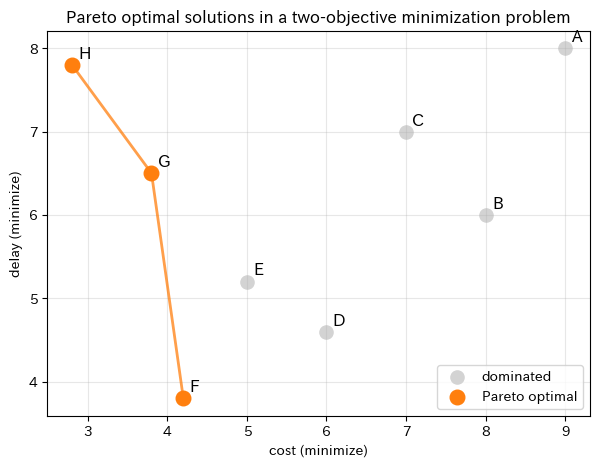

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

points = np.array(
    [
        [9.0, 8.0],
        [8.0, 6.0],
        [7.0, 7.0],
        [6.0, 4.6],
        [5.0, 5.2],
        [4.2, 3.8],
        [3.8, 6.5],
        [2.8, 7.8],
    ]
)
labels = list("ABCDEFGH")


def is_dominated_minimize(values: np.ndarray, index: int) -> bool:
    '''Return True if values[index] is dominated in a minimization problem.'''
    target = values[index]
    others = np.delete(values, index, axis=0)
    no_worse = np.all(others <= target, axis=1)
    strictly_better = np.any(others < target, axis=1)
    return bool(np.any(no_worse & strictly_better))


is_dominated = np.array([is_dominated_minimize(points, i) for i in range(len(points))])
pareto_points = points[~is_dominated]

plt.figure(figsize=(7.0, 5.0))
plt.scatter(points[is_dominated, 0], points[is_dominated, 1], s=90, color="lightgray", label="dominated")
plt.scatter(pareto_points[:, 0], pareto_points[:, 1], s=110, color="tab:orange", label="Pareto optimal")

for label, (cost, delay) in zip(labels, points):
    plt.text(cost + 0.08, delay + 0.08, label, fontsize=12)

plt.plot(
    pareto_points[np.argsort(pareto_points[:, 0]), 0],
    pareto_points[np.argsort(pareto_points[:, 0]), 1],
    color="tab:orange",
    linewidth=2,
    alpha=0.75,
)
plt.xlabel("cost (minimize)")
plt.ylabel("delay (minimize)")
plt.title("Pareto optimal solutions in a two-objective minimization problem")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


オレンジ色の点は，ほかの点からパレート優越されていない。これらを **パレート最適解**（Pareto optimal solution）と呼ぶ。パレート最適解を目的関数値の空間に描いた曲線や面を **パレートフロント**（Pareto front）と呼ぶ。

ここで大事なのは，パレート最適解が 1 個とは限らない点である。左下へ行ければ両方改善なので迷わない。しかし，左へ行くほど上へ，あるいは下へ行くほど右へ動くような関係では，費用と遅延のどちらを重く見るかで選ぶ点が変わる。


(sec:weighted-sum-limit)=

## 3. 重み付き和で 1 目的にしてよいのか

多目的最適化を簡単に扱う方法として，重み付き和

$$
F(\boldsymbol{x})
= w_1 f_1(\boldsymbol{x}) + w_2 f_2(\boldsymbol{x}) + \cdots + w_m f_m(\boldsymbol{x})
$$

を作り，1 目的最適化に戻す考え方がある。

これは悪い方法ではない。意思決定者が「費用 1 単位と性能 1 単位の交換比率」を明確に決められるなら，実装しやすく，結果も解釈しやすい。一方で，授業の最初から重みを 1 つに固定してしまうと，どのようなトレードオフが存在するかを見落としやすい。

したがって，第11回では先にパレートフロントを出し，その後で「どの点を採用するか」を考える。


(sec:optuna-moo)=

## 4. Optuna による多目的最適化

Optuna はハイパーパラメータ最適化でよく使われるライブラリだが，ブラックボックス最適化の道具としても使える。多目的最適化では，`create_study` に複数の `directions` を渡し，目的関数から複数の値を返す。

ここでは，架空の「軽量な保護ケース設計」を考える。設計変数は次の 3 つである。

- `thickness`: ケースの厚み。厚いほど保護性能は上がるが，重く高くなる。
- `rib_count`: 補強リブの本数。多いほど保護性能は上がるが，製造コストが上がる。
- `material`: 材料。軽さ，コスト，保護性能に影響する。

目的は **費用を最小化** し，**保護性能を最大化** することである。


In [2]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def evaluate_case_design(thickness: float, rib_count: int, material: str) -> tuple[float, float]:
    '''Evaluate a toy protective-case design.

    Args:
        thickness: Case thickness in millimeters.
        rib_count: Number of reinforcement ribs.
        material: Material name.

    Returns:
        A pair of (cost, protection_score). Cost is minimized and protection is maximized.
    '''
    material_table = {
        "ABS": {"cost": 1.00, "strength": 1.00, "weight": 1.00},
        "PLA": {"cost": 0.85, "strength": 0.82, "weight": 0.92},
        "nylon": {"cost": 1.55, "strength": 1.28, "weight": 0.88},
        "carbon": {"cost": 2.40, "strength": 1.65, "weight": 0.72},
    }
    m = material_table[material]

    cost = 1200 * m["cost"] + 260 * thickness + 95 * rib_count
    protection = (
        42 * np.log1p(1.45 * thickness) * m["strength"]
        + 2.7 * np.sqrt(rib_count + 1) * m["strength"]
        - 4.5 * max(thickness - 4.2, 0.0) ** 2
    )

    # 軽い材料は持ち運びやすいので，授業用の例では保護スコアに少し加点する。
    protection += 8.0 * (1.0 - m["weight"])
    return float(cost), float(protection)


def objective(trial: optuna.Trial) -> tuple[float, float]:
    thickness = trial.suggest_float("thickness", 0.8, 6.0)
    rib_count = trial.suggest_int("rib_count", 0, 12)
    material = trial.suggest_categorical("material", ["ABS", "PLA", "nylon", "carbon"])
    return evaluate_case_design(thickness, rib_count, material)


sampler = optuna.samplers.NSGAIISampler(seed=11)
study = optuna.create_study(directions=["minimize", "maximize"], sampler=sampler)
study.optimize(objective, n_trials=120)

len(study.trials), len(study.best_trials)


/Users/mriki/MyBooks/NITIC-ConbinatorialOptimization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(120, 24)

`study.trials` は試した候補全体であり，`study.best_trials` は Optuna が見つけた非劣解集合である。多目的最適化では `best_trial` ではなく `best_trials` になる点に注意する。


In [3]:
best_rows = []
for trial in study.best_trials:
    cost, protection = trial.values
    best_rows.append(
        {
            "trial": trial.number,
            "cost": cost,
            "protection": protection,
            **trial.params,
        }
    )

best_rows = sorted(best_rows, key=lambda row: row["cost"])
for row in best_rows[:8]:
    print(
        f"trial={row['trial']:3d}  cost={row['cost']:7.1f}  "
        f"protection={row['protection']:6.2f}  "
        f"thickness={row['thickness']:.2f}  ribs={row['rib_count']:2d}  material={row['material']}"
    )


trial= 48  cost= 1367.7  protection= 34.05  thickness=0.97  ribs= 1  material=PLA
trial= 57  cost= 1459.9  protection= 40.33  thickness=1.00  ribs= 0  material=ABS
trial=  0  cost= 1471.7  protection= 46.19  thickness=1.74  ribs= 0  material=PLA
trial=  4  cost= 1654.0  protection= 49.99  thickness=1.38  ribs= 1  material=ABS
trial= 97  cost= 1659.1  protection= 55.14  thickness=2.46  ribs= 0  material=PLA
trial=  3  cost= 1845.7  protection= 56.62  thickness=2.45  ribs= 2  material=PLA
trial= 75  cost= 2044.1  protection= 75.86  thickness=3.25  ribs= 0  material=ABS
trial=119  cost= 2418.8  protection= 82.08  thickness=3.59  ribs= 3  material=ABS


### 4.1 パレートフロントを描く

次に，全試行と非劣解集合を散布図にする。横軸は費用なので左ほど良く，縦軸は保護性能なので上ほど良い。したがって，図の左上側にある点ほど望ましい。


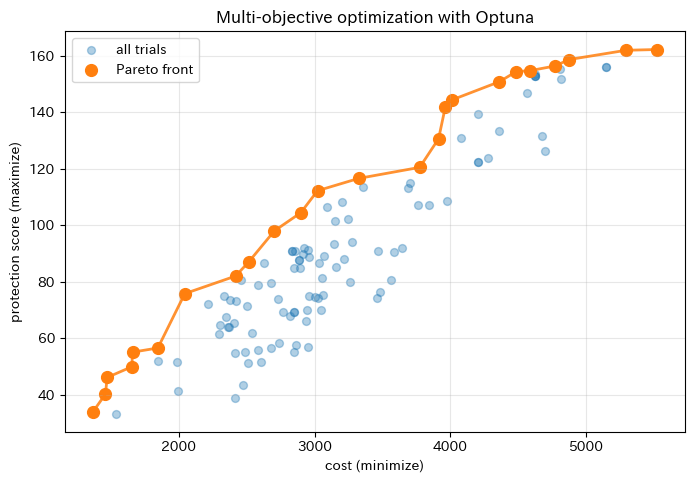

In [4]:
trial_values = np.array([trial.values for trial in study.trials if trial.values is not None])
best_values = np.array([trial.values for trial in study.best_trials])
best_values = best_values[np.argsort(best_values[:, 0])]

plt.figure(figsize=(8.0, 5.2))
plt.scatter(trial_values[:, 0], trial_values[:, 1], s=32, alpha=0.35, color="tab:blue", label="all trials")
plt.scatter(best_values[:, 0], best_values[:, 1], s=72, color="tab:orange", label="Pareto front")
plt.plot(best_values[:, 0], best_values[:, 1], color="tab:orange", linewidth=2.0, alpha=0.85)
plt.xlabel("cost (minimize)")
plt.ylabel("protection score (maximize)")
plt.title("Multi-objective optimization with Optuna")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


図を見ると，費用を下げるほど保護性能が下がり，保護性能を上げるほど費用が上がる傾向が見える。この曲線上のどこを選ぶかは，アルゴリズムだけでは決まらない。

たとえば，学校の PBL で「予算は 2500 円程度まで」と決めているなら，その範囲内で最も保護性能の高い点を選ぶのが自然である。一方，コンテストで性能を重視するなら，費用が多少上がっても右上の点を選ぶかもしれない。


### 4.2 採用候補を条件で絞る

パレートフロントを出した後は，人間が使う条件で候補を絞る。ここでは「費用 2500 以下」という条件を後から入れる。


In [5]:
budget = 2500.0
feasible_best = [trial for trial in study.best_trials if trial.values[0] <= budget]
chosen = max(feasible_best, key=lambda trial: trial.values[1])

print(f"budget: {budget:.0f}")
print(f"chosen trial: {chosen.number}")
print(f"cost: {chosen.values[0]:.1f}")
print(f"protection: {chosen.values[1]:.2f}")
print("params:", chosen.params)


budget: 2500
chosen trial: 119
cost: 2418.8
protection: 82.08
params: {'thickness': 3.591353617077493, 'rib_count': 3, 'material': 'ABS'}


このように，多目的最適化は「全部を 1 つの点へ自動で決めてくれる道具」というより，「よい候補集合を見せ，人間の判断を助ける道具」と考えるとよい。


(sec:optuna-api)=

## 5. Optuna の書き方を整理する

1 目的最適化と多目的最適化の違いは大きくない。最小限の形は次の通りである。

```python
def objective(trial):
    x = trial.suggest_float("x", 0.0, 1.0)
    y = trial.suggest_int("y", 0, 10)
    cost = ...
    performance = ...
    return cost, performance

study = optuna.create_study(directions=["minimize", "maximize"])
study.optimize(objective, n_trials=100)

pareto_trials = study.best_trials
```

重要なのは，`objective` がタプルを返すこと，`directions` が目的の数だけ必要なこと，そして結果が `best_trials` になることである。


### 5.1 Optuna の用語

Optuna のコードを読むときは，次の対応を意識するとよい。

| Optuna の名前 | この授業での意味 |
|---|---|
| `trial` | 1 つの候補解を試すこと |
| `suggest_float` / `suggest_int` / `suggest_categorical` | 探索空間から設計変数を選ぶこと |
| `objective` | 候補解を評価して目的関数値を返す関数 |
| `study` | 探索実験全体 |
| `sampler` | 次に試す候補を決めるアルゴリズム |
| `directions` | 各目的を最小化するか最大化するか |
| `best_trials` | 非劣解集合，つまり Optuna が見つけたパレート候補 |

1 目的最適化のときは `best_trial` を見ればよかった。しかし，多目的最適化では「この 1 個が絶対に最良」とは言えないので，`best_trials` を見る。


### 5.2 結果を表として見る

授業や PBL では，最終的な図だけでなく，どの候補を試したかを表で確認すると説明しやすい。ここでは追加ライブラリを増やさないため，`study.trials` から必要な情報だけを取り出して表示する。


In [6]:
for trial in study.trials[:5]:
    print(
        f"trial={trial.number:3d}  "
        f"cost={trial.values[0]:7.1f}  "
        f"protection={trial.values[1]:6.2f}  "
        f"params={trial.params}"
    )


trial=  0  cost= 1471.7  protection= 46.19  params={'thickness': 1.7374023821592, 'rib_count': 0, 'material': 'PLA'}
trial=  1  cost= 1995.3  protection= 41.32  params={'thickness': 0.866460235871165, 'rib_count': 6, 'material': 'ABS'}
trial=  2  cost= 3481.6  protection= 76.59  params={'thickness': 5.448301685482423, 'rib_count': 11, 'material': 'PLA'}
trial=  3  cost= 1845.7  protection= 56.62  params={'thickness': 2.44511002038521, 'rib_count': 2, 'material': 'PLA'}
trial=  4  cost= 1654.0  protection= 49.99  params={'thickness': 1.3806384063722341, 'rib_count': 1, 'material': 'ABS'}


```{hint} NSGA-II とは何か
:class: dropdown

このページでは `NSGAIISampler` を使った。NSGA-II は，多目的進化計算でよく使われる代表的なアルゴリズムである。集団中の候補をパレート優越の関係でランク付けし，さらに解が一箇所へ固まりすぎないように多様性も考慮する。

ただし，本ページの目的は NSGA-II の詳細実装ではなく，Optuna を使って「多目的最適化の入力・出力・可視化」を扱えるようになることである。NSGA-II の細部は，PBL で必要になった人が調べればよい。
```


(sec:model-complexity)=

## 6. 例題：精度とモデルの小ささを同時に見る

次は，機械学習モデルのハイパーパラメータ調整を多目的最適化として見る例である。分類精度だけを最大化すると，モデルが大きくなりすぎたり，説明しにくくなったりすることがある。

ここでは `scikit-learn` の digits データセットを使い，決定木分類器について

$$
\text{validation accuracy} \uparrow,\qquad
\text{number of tree nodes} \downarrow
$$

を同時に考える。`number of tree nodes` は，モデルの複雑さの簡単な代理指標である。


In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

digits = load_digits()
X_train, X_valid, y_train, y_valid = train_test_split(
    digits.data,
    digits.target,
    test_size=0.35,
    random_state=11,
    stratify=digits.target,
)


def tree_objective(trial: optuna.Trial) -> tuple[float, int]:
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=11,
    )
    model.fit(X_train, y_train)
    accuracy = model.score(X_valid, y_valid)
    node_count = int(model.tree_.node_count)
    return float(accuracy), node_count


tree_study = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=optuna.samplers.NSGAIISampler(seed=22),
)
tree_study.optimize(tree_objective, n_trials=100)

len(tree_study.trials), len(tree_study.best_trials)


(100, 32)

横軸をノード数，縦軸を精度にすると，左上ほど「小さくて精度が高い」モデルである。完全に左上の 1 点だけが存在するとは限らないので，パレートフロントを見る。


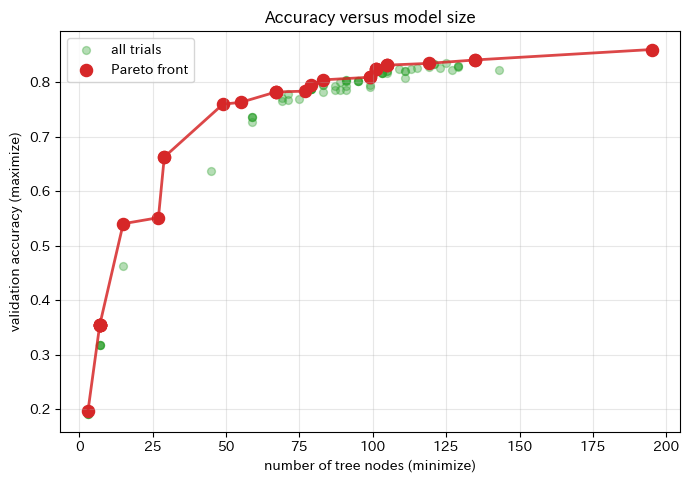

In [8]:
tree_values = np.array([trial.values for trial in tree_study.trials if trial.values is not None])
tree_best_values = np.array([trial.values for trial in tree_study.best_trials])
tree_best_values = tree_best_values[np.argsort(tree_best_values[:, 1])]

plt.figure(figsize=(8.0, 5.2))
plt.scatter(tree_values[:, 1], tree_values[:, 0], s=32, alpha=0.35, color="tab:green", label="all trials")
plt.scatter(
    tree_best_values[:, 1],
    tree_best_values[:, 0],
    s=76,
    color="tab:red",
    label="Pareto front",
)
plt.plot(tree_best_values[:, 1], tree_best_values[:, 0], color="tab:red", linewidth=2.0, alpha=0.85)
plt.xlabel("number of tree nodes (minimize)")
plt.ylabel("validation accuracy (maximize)")
plt.title("Accuracy versus model size")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


### 6.1 どのモデルを採用するか

最終的にモデルを 1 つ選ぶには，授業や PBL の目的に応じた条件を後から入れる。たとえば「精度 0.82 以上を満たす中で，最も小さい木を採用する」と決めると，次のように書ける。


In [9]:
min_accuracy = 0.82
accurate_trials = [trial for trial in tree_study.best_trials if trial.values[0] >= min_accuracy]
compact_trial = min(accurate_trials, key=lambda trial: trial.values[1])

print(f"minimum accuracy: {min_accuracy:.2f}")
print(f"chosen trial: {compact_trial.number}")
print(f"accuracy: {compact_trial.values[0]:.3f}")
print(f"tree nodes: {compact_trial.values[1]}")
print("params:", compact_trial.params)


minimum accuracy: 0.82
chosen trial: 18
accuracy: 0.824
tree nodes: 101.0
params: {'max_depth': 15, 'min_samples_split': 24, 'min_samples_leaf': 8, 'criterion': 'log_loss'}


この選び方は，アルゴリズムの内部で目的を勝手に 1 つへ混ぜていない。まず精度と複雑さのトレードオフを見せ，その後で採用条件を明示している。発表資料ではこの順番が重要である。


(sec:pbl-moo)=

## 7. PBL へのつなげ方

PBL で扱う題材も，多目的最適化として見直せることが多い。たとえば次のように整理できる。

| 題材 | 最小化したい目的 | 最大化したい目的 | 設計変数の例 |
|---|---|---|---|
| デッキ編成 | 総コスト，事故率 | 勝率，対応範囲 | カード枚数，役割配分 |
| 配送ルート | 距離，費用，遅延 | 顧客満足度 | 訪問順，車両数，出発時刻 |
| 製品設計 | 重量，材料費 | 強度，耐久性 | 厚み，材料，構造 |
| 学習計画 | 学習時間，負担 | 得点，理解度 | 教材配分，復習間隔 |

ポイントは，最初から「総合点」を 1 つだけ作らないことである。まず目的を分けて書き，どの目的同士が衝突しそうかを考える。その後で，Optuna などを使って候補集合を作り，最後に採用条件を議論する。


### 7.1 PBL での提出物に入れるとよい図

多目的最適化を使った場合，発表資料には次の図を入れると説明しやすい。

- 全試行の散布図。
- パレートフロントを強調した散布図。
- 採用した 1 点と，採用理由を示す注釈。
- 予算や重量など，後から入れた条件を示す線。

最終的に 1 つの案を選ぶとしても，その案だけを見せるより，「ほかにどのような候補があり，なぜこの案にしたか」を見せる方が説得力が高い。


### 7.2 Optuna に向いている PBL テーマ

Optuna は，次のような条件を満たすテーマと相性がよい。

- 候補を 1 回評価する関数を Python で書ける。
- 変数が連続値，整数，カテゴリの組み合わせで表せる。
- 評価関数の中身が微分できなくてもよい。
- 目的が 2 個から 3 個程度で，散布図として説明できる。

逆に，訪問順のような順列をそのまま最適化したい場合は，Optuna だけで綺麗に書くのが難しいことがある。その場合でも，「配送ルートを作るヒューリスティックのパラメータを Optuna で調整する」のように，問題を少し変形すれば使えることがある。


## 8. 演習

### 演習 1

第4節のケース設計問題で，`n_trials` を 30，120，400 に変えてパレートフロントを比較せよ。試行回数を増やすと，どのあたりの点が増えるだろうか。

### 演習 2

`budget = 2500.0` を 1800，3000，4500 に変え，採用される設計がどう変わるかを確認せよ。

### 演習 3

自分の PBL テーマについて，最小化したい目的を 2 つ，最大化したい目的を 1 つ書き出せ。さらに，Optuna の `trial.suggest_*` で表せそうな設計変数を 3 つ以上挙げよ。


### 演習 4

第6節の決定木の例で，採用条件を「精度 0.85 以上」や「ノード数 40 以下」に変えると，どの試行が選ばれるかを確認せよ。条件を厳しくしすぎると，候補が存在しない場合がある。そのときは，条件そのものが現実的かどうかを議論せよ。


## 9. まとめ

- 多目的最適化では，目的関数値をベクトルとして扱う。
- パレート優越は「すべての目的で悪くなく，少なくとも 1 つで良い」という比較である。
- パレート最適解は 1 つとは限らず，非劣解集合として得られる。
- Optuna では `directions` を複数指定し，目的関数から複数の値を返すことで多目的最適化を書ける。
- 多目的最適化の結果は，人間の制約や価値判断と組み合わせて採用案を決める。


## 参考リンク

- [Optuna: Multi-objective Optimization with Optuna](https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/002_multi_objective.html)
- [Optuna API Reference: NSGAIISampler](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.NSGAIISampler.html)
- [Deb et al. (2002), A fast and elitist multiobjective genetic algorithm: NSGA-II](https://ieeexplore.ieee.org/document/996017)
